In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

In [9]:
VAL_DIR = "../dataset/PlantVillage_5Class/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names

print(class_names)

Found 1068 files belonging to 5 classes.
['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight']


In [2]:
VAL_DIR = "../dataset/PlantVillage_5Class/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names

Found 1068 files belonging to 5 classes.


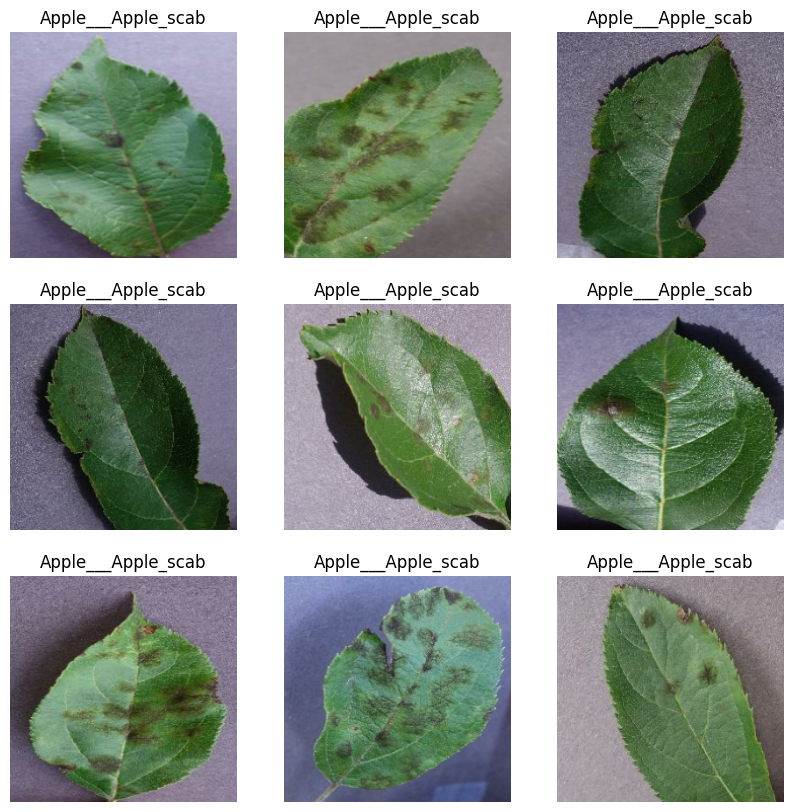

In [10]:
plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ResNet50", "DenseNet121", "MobileNetV3"],
    "Accuracy": [99.53, 97.85, 99.81],
    "Training Time (sec)": [1133, 2670, 398]
})

print(results)

         Model  Accuracy  Training Time (sec)
0     ResNet50     99.53                 1133
1  DenseNet121     97.85                 2670
2  MobileNetV3     99.81                  398


# Conclusion

Three CNN models were evaluated for plant disease classification.

- ResNet50 achieved high accuracy but required longer training time.
- DenseNet121 required the longest training time.
- MobileNetV3 achieved the highest accuracy and fastest training speed.

Therefore, MobileNetV3 is the most suitable model for this classification task.

In [5]:
model = tf.keras.models.load_model(
    "../models/mobilenetv3.keras"
)

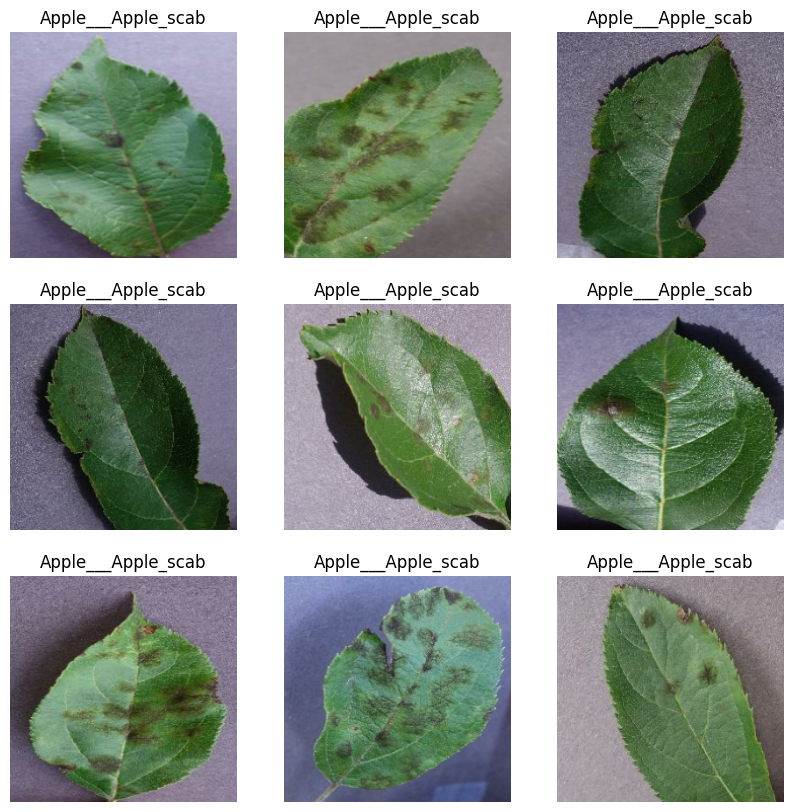

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>